In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

import src
import pandas as pd

import matplotlib as mpl
import matplotlib.pyplot as plt

mpl.rc("text", usetex=True)
mpl.rc("font", family="serif")

/Users/gperaza/Research/informal-jobs-model/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


We loaded the already standardized databases from Notebook 02.

In [2]:
enoe = pd.read_parquet(ROOT / "outputs/enoe_harmonized.parquet")
od = pd.read_parquet(ROOT / "outputs/od_harmonized.parquet")

We filtered the database to include only those municipalities that appear in both databases and are also among the municipalities of interest:

- Guadalajara
- Zapopan
- Tlaquepaque
- Tlajomulco
- Tonala
- El Salto
- Juanacatlan 
- Ixtlahuacan Membrillos
- Zapotlanejo 
- Tala

In [3]:
enoe_common, od_common, geography_summary = src.filter_common_geography(enoe, od)
print(geography_summary)

print()
print(f"ENOE workers in common geography: {len(enoe_common):,}")
print(f"OD workers in common geography: {len(od_common):,}")
print(f"Common municipalities: {geography_summary['common'].sum()}")

                municipio   enoe     od  common
0             guadalajara   True   True    True
1                 zapopan   True   True    True
2             tlaquepaque   True   True    True
3              tlajomulco   True   True    True
4                  tonala   True   True    True
5                el_salto   True   True    True
6             juanacatlan  False   True   False
7  ixtlahuacan_membrillos   True   True    True
8             zapotlanejo  False   True   False
9                    tala   True  False   False

ENOE workers in common geography: 5,280
OD workers in common geography: 25,053
Common municipalities: 7


## Informality benchmark

To get an idea of what percentage of the population ENOE represents in terms of informality, we calculated two benchmark informality rates:

* **Unweighted informality rate**: percentage directly observed in the sample.
* **Weighted informality rate**: percentage calculated using the ENOE `survey_weight` expansion factor.

In [4]:
benchmark = src.calculate_weighted_informality_rate(enoe_common)

weighted_rate = benchmark.loc[0, "weighted_informality_rate"]
unweighted_rate = benchmark.loc[0, "unweighted_informality_rate"]

print(f"Unweighted ENOE informality rate: {unweighted_rate:.2%}")
print(f"Weighted ENOE informality rate: {weighted_rate:.2%}")

Unweighted ENOE informality rate: 40.02%
Weighted ENOE informality rate: 39.59%


## ENOE and OD distributions

To determine which variables we will use as predictors in the machine learning model, we analyzed their distribution across both surveys, comparing (for each variable and each category) the weighted proportion in ENOE and OD.

In [5]:
# We don't consider the “sector” attribute because it requires a more detailed analysis
predictor_columns = ["genero", "ocupacion", "edad_cat", "escolaridad", "municipio", "estado_civil", "parentesco", "tamano_viv_cat"]
distribution_comparison = src.compare_weighted_distributions(enoe_common, od_common, predictor_columns)
distribution_comparison.reindex(distribution_comparison["difference_pp"].abs().sort_values(ascending=False).index).head(20)

,variable,category,enoe_population,od_population,enoe_share,od_share,difference_pp
15,escolaridad,no_especificado,683,353411,0.000272,0.157531,15.725882
17,escolaridad,primaria_o_secundaria,1042164,606491,0.415495,0.27034,-14.515457
26,estado_civil,casado,961468,1021169,0.383323,0.455181,7.185826
5,ocupacion,trabajador,2003552,1934134,0.798785,0.86213,6.334479
9,edad_cat,25_49,1412009,1396808,0.562946,0.62262,5.967362
30,estado_civil,soltero,930746,702902,0.371074,0.313315,-5.775922
25,municipio,zapopan,628882,673434,0.250726,0.30018,4.945412
2,ocupacion,independiente,445409,289963,0.177578,0.12925,-4.832823
0,genero,F,1089998,873248,0.434565,0.389246,-4.53197
1,genero,H,1418250,1370188,0.565435,0.610754,4.53197


<>:96: SyntaxWarning: invalid escape sequence '\%'
<>:96: SyntaxWarning: invalid escape sequence '\%'
/var/folders/p7/pgt8wgsx4qz0pxtvkxnwzct40000gn/T/ipykernel_29711/4228406643.py:96: SyntaxWarning: invalid escape sequence '\%'
  ax.set_ylabel("Proporción ponderada [\%]")


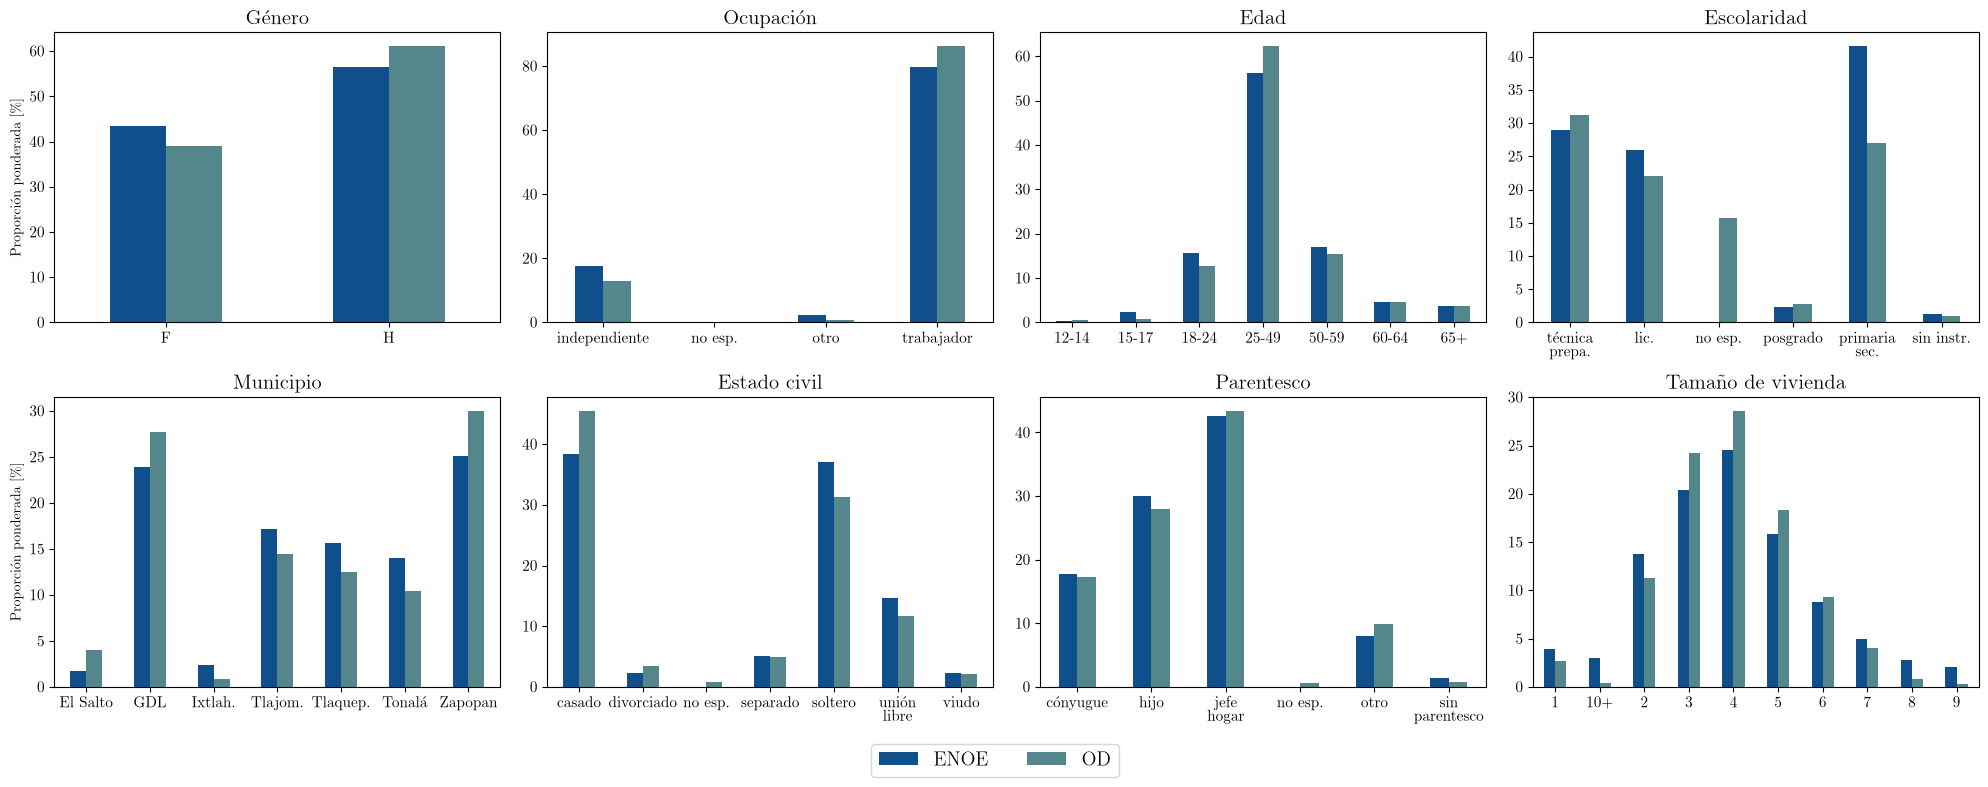

In [6]:
variables = ["genero", "ocupacion", "edad_cat", "escolaridad", "municipio", "estado_civil", "parentesco", "tamano_viv_cat"]

plot_titles = {
    "genero": "Género",
    "ocupacion": "Ocupación",
    "edad_cat": "Edad",
    "escolaridad": "Escolaridad",
    "municipio": "Municipio",
    "estado_civil": "Estado civil",
    "parentesco": "Parentesco",
    "tamano_viv_cat": "Tamaño de vivienda"
}

tick_labels = {
    "ocupacion": {
        "independiente": "independiente",
        "no_especificado": "no esp.",
        "otro": "otro",
        "trabajador": "trabajador"
    },
    "escolaridad": {
        "carrera_tecnica_o_preparatoria": "técnica\nprepa.",
        "primaria_o_secundaria": "primaria\nsec.",
        "licenciatura": "lic.",
        "postgrado": "posgrado",
        "sin_instruccion": "sin instr.",
        "no_especificado": "no esp."
    },
    "edad_cat": {
        "25_49": "25-49", 
        "18_24": "18-24",
        "15_17": "15-17",
        "50_59": "50-59", 
        "65_y_mas": "65+",
        "60_64": "60-64", 
        "12_14": "12-14"
    },
    "municipio": {
        "el_salto": "El Salto",
        "guadalajara": "GDL",
        "ixtlahuacan_membrillos": "Ixtlah.",
        "tlajomulco": "Tlajom.",
        "tlaquepaque": "Tlaquep.",
        "tonala": "Tonalá",
        "zapopan": "Zapopan"
    },
    "estado_civil": {
        "casado": "casado",
        "divorciado": "divorciado",
        "no_especificado": "no esp.",
        "separado": "separado",
        "soltero": "soltero",
        "union_libre": "unión\nlibre",
        "viudo": "viudo"
    },
    "parentesco": {
        "conyuge": "cónyugue",
        "hijo": "hijo",
        "jefe_del_hogar": "jefe\nhogar",
        "no_especificado": "no esp.",
        "otro_parentesco": "otro",
        "sin_parentesco": "sin\nparentesco"
    },
    "tamano_viv_cat": {
        "1": "1",
        "2": "2",
        "3": "3",
        "4": "4",
        "5": "5",
        "6": "6",
        "7": "7",
        "8": "8",
        "9": "9",
        "10_y_mas": "10+"
    }
}

ENOE_color = (0.06, 0.31, 0.55)
OD_color = (0.33, 0.53, 0.55)

fig, axes = plt.subplots(2, 4, figsize=(20, 8))

for i, (ax, variable) in enumerate(zip(axes.flatten(), variables)):
    plot_data = distribution_comparison[distribution_comparison["variable"] == variable].copy()
    plot_data = plot_data.set_index("category")[["enoe_share", "od_share"]] * 100

    if variable in tick_labels:
        plot_data = plot_data.rename(index=tick_labels[variable])

    plot_data.plot(kind="bar", ax=ax, color=[ENOE_color, OD_color])

    ax.set_title(plot_titles[variable], fontsize=15)
    ax.set_xlabel("")

    if i in [0, 4]:
        ax.set_ylabel("Proporción ponderada [\%]")
    else:
        ax.set_ylabel("")

    ax.tick_params(axis="x", rotation=0, labelsize=11)
    ax.tick_params(axis="y", labelsize=11)

    ax.get_legend().remove()

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, ["ENOE", "OD"], loc="lower center", ncol=2, fontsize=14, bbox_to_anchor=(0.5, 0.01))

output_dir = ROOT / "outputs/figures"
output_dir.mkdir(parents=True, exist_ok=True)

plt.tight_layout(rect=[0, 0.07, 1, 1])

fig.savefig(output_dir / "weighted_distribution_comparison.pdf", bbox_inches="tight")
fig.savefig(output_dir / "weighted_distribution_comparison.png", dpi=600, bbox_inches="tight")

plt.show()

Overall, most predictors show reasonably similar weighted distributions across both surveys, particularly gender, age, occupation, and relationship to the household head. The largest discrepancy is observed in educational level, mainly due to the substantial proportion of `no_especificado` observations in OD. Differences are also present in municipality, marital status, and household size, which should be considered when transferring models between both datasets.

## ENOE informality per predictor

It is also important for the machine learning model (similarly, with regard to the predictor variables) to analyze how strongly each candidate variable is associated with informality within ENOE. With this in mind, we seek to calculate the weighted ENOE informality rate for each variable and category, using the `survey_weight`.

In [7]:
informality_columns = ["genero", "ocupacion", "edad_cat", "escolaridad", "municipio", "estado_civil", "parentesco", "tamano_viv_cat", "sector"]
informality_profiles = src.calculate_informality_profiles(enoe_common, informality_columns)

<>:19: SyntaxWarning: invalid escape sequence '\%'
<>:19: SyntaxWarning: invalid escape sequence '\%'
/var/folders/p7/pgt8wgsx4qz0pxtvkxnwzct40000gn/T/ipykernel_29711/103292693.py:19: SyntaxWarning: invalid escape sequence '\%'
  ax.set_ylabel("Informalidad [\%]")


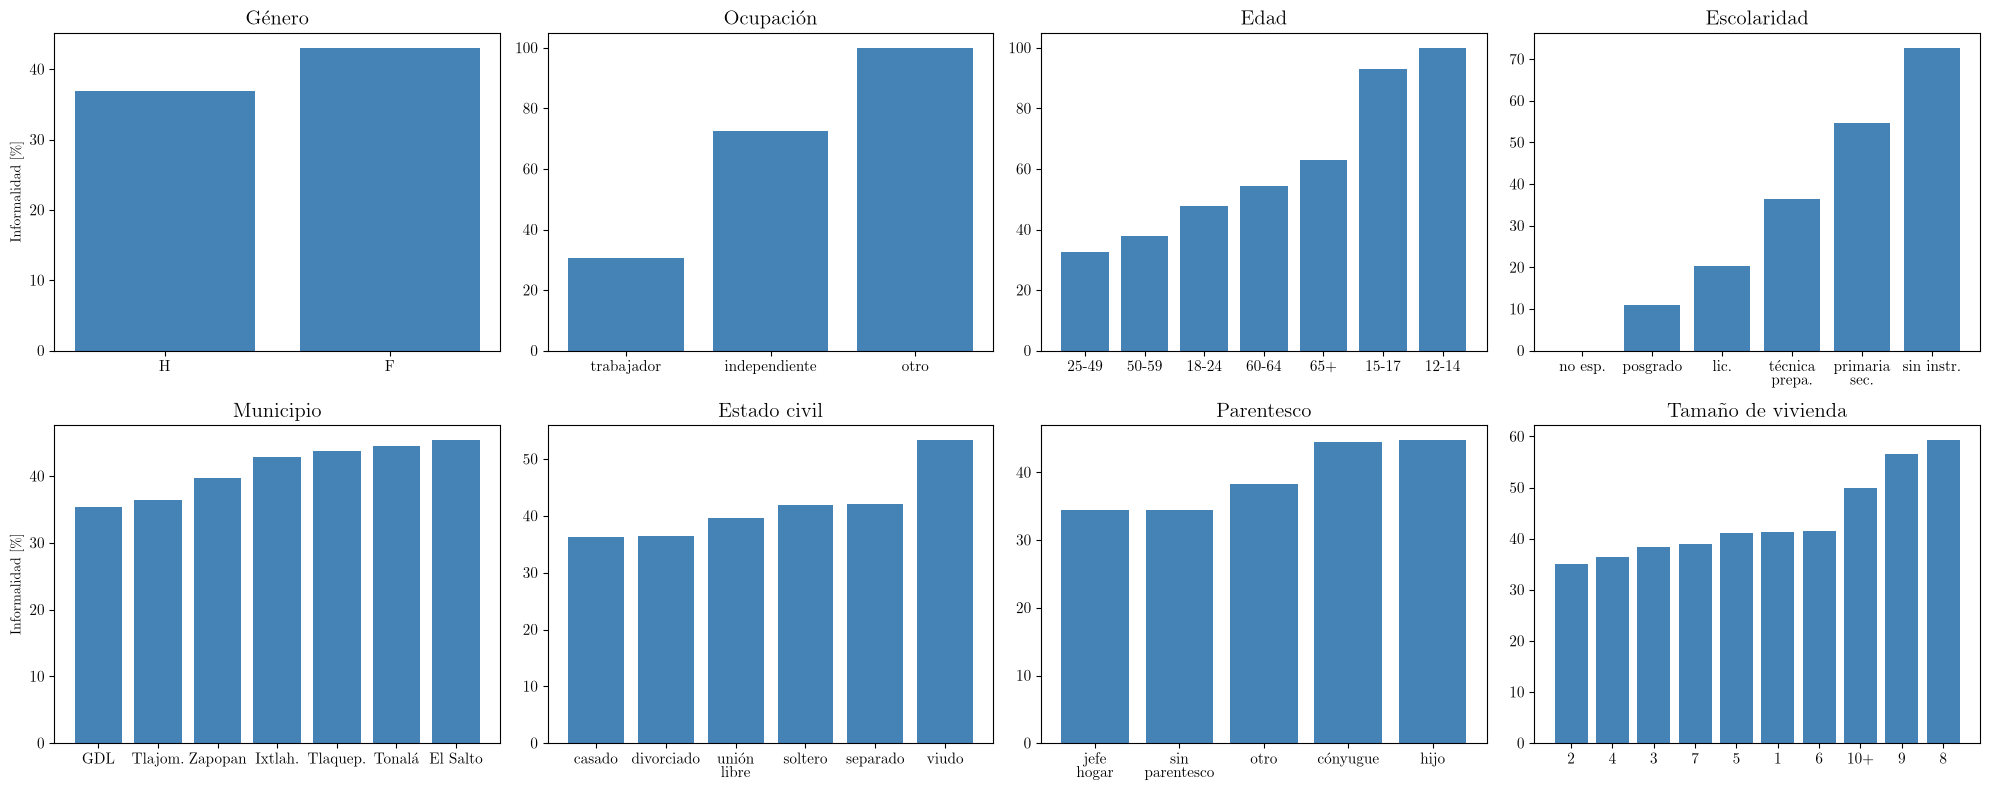

In [8]:
informality_color = (0.27, 0.51, 0.71)

fig, axes = plt.subplots(2, 4, figsize=(20, 8))

for i, (ax, variable) in enumerate(zip(axes.flatten(), variables)):
    plot_data = informality_profiles[informality_profiles["variable"] == variable].copy()
    plot_data["informality_rate_percent"] = plot_data["informality_rate"] * 100
    plot_data = plot_data.sort_values("informality_rate")

    if variable in tick_labels:
        plot_data["category"] = plot_data["category"].replace(tick_labels[variable])

    ax.bar(plot_data["category"], plot_data["informality_rate_percent"], color=informality_color)

    ax.set_title(plot_titles[variable], fontsize=15)
    ax.set_xlabel("")

    if i in [0, 4]:
        ax.set_ylabel("Informalidad [\%]")
    else:
        ax.set_ylabel("")

    ax.tick_params(axis="x", rotation=0, labelsize=11)
    ax.tick_params(axis="y", labelsize=11)

output_dir = ROOT / "outputs/figures"
output_dir.mkdir(parents=True, exist_ok=True)

plt.tight_layout()

fig.savefig(output_dir / "informality_profiles.pdf", bbox_inches="tight")
fig.savefig(output_dir / "informality_profiles.png", dpi=600, bbox_inches="tight")

plt.show()

Here we can see some differences in informality rates across several categories. Occupation and educational level exhibit particularly strong contrasts, suggesting that they may provide important predictive information for the model. Age also shows considerable variation, while marital status, relationship to the household head, and dwelling size present more moderate differences. In contrast, gender and municipality exhibit comparatively smaller variations in informality rates.

## Missing data 

To analyze the missing information regarding the population represented by each survey, we used the variables of interest to determine how much of this information is unspecified or missing. 

In [9]:
missing_columns = ["genero", "ocupacion", "edad_cat", "escolaridad", "municipio", "estado_civil", "parentesco", "tamano_viv_cat", "sector"]
enoe_missingness = src.calculate_missingness(enoe_common, missing_columns, "survey_weight")
od_missingness = src.calculate_missingness(od_common, missing_columns, "expansion_factor")
missingness_comparison = enoe_missingness.merge(od_missingness, on="variable", suffixes=("_enoe", "_od"))

In [10]:
missingness_display = missingness_comparison[["variable", "weighted_missing_share_enoe", "weighted_missing_share_od"]].copy()
missingness_display["weighted_missing_share_enoe"] *= 100
missingness_display["weighted_missing_share_od"] *= 100

print(missingness_display.round(2))

         variable  weighted_missing_share_enoe  weighted_missing_share_od
0          genero                         0.00                       0.00
1       ocupacion                         0.00                       0.08
2        edad_cat                         0.00                       0.00
3     escolaridad                         0.03                      15.75
4       municipio                         0.00                       0.00
5    estado_civil                         0.00                       0.86
6      parentesco                         0.00                       0.66
7  tamano_viv_cat                         0.00                       0.00
8          sector                         0.54                      30.16


From the missing information, we can conclude that ENOE provides nearly complete information for all candidate predictors, while OD shows substantial missingness in educational level and especially in economic sector. The 15.75% weighted missingness in education suggests that models relying on this variable may require an alternative specification for observations where education is unavailable. The 30.16% missingness in economic sector confirms the need for a dedicated imputation model before sector can be used reliably in subsequent analyses.

## Economic sector analysis

Finally, given that previous studies on the assignment of informal jobs identified balancing problems associated primarily with classification by economic sector, we analyzed the weighted distribution of workers across the various sectors for ENOE and OD, considering only those with a known sector. These distributions will serve as a reference for subsequently evaluating the results of the economic sector assignment for OD workers with missing or unknown information.

In [11]:
sector_missing = missingness_display[missingness_display["variable"] == "sector"]
sector_comparison = src.compare_known_sector_distributions(enoe_common, od_common)

<>:19: SyntaxWarning: invalid escape sequence '\%'
<>:19: SyntaxWarning: invalid escape sequence '\%'
/var/folders/p7/pgt8wgsx4qz0pxtvkxnwzct40000gn/T/ipykernel_29711/4065131370.py:19: SyntaxWarning: invalid escape sequence '\%'
  ax.set_ylabel("Proporción ponderada [\%]", fontsize=12)


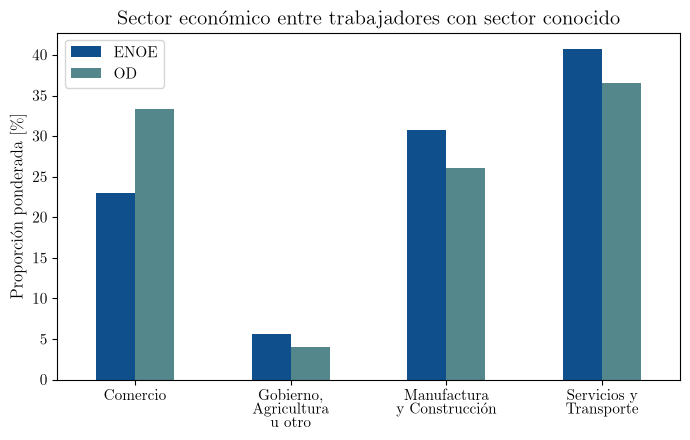

In [12]:
tick_labels = {
    "comercio": "Comercio",
    "gobierno_otro_agricultura": "Gobierno,\nAgricultura\nu otro",
    "manufactura_construccion": "Manufactura\ny Construcción",
    "servicios_transporte": "Servicios y\nTransporte"
}

ENOE_color = (0.06, 0.31, 0.55)
OD_color = (0.33, 0.53, 0.55)

plot_data = sector_comparison.set_index("sector")[["enoe_share", "od_share"]] * 100
plot_data = plot_data.rename(index=tick_labels)

fig, ax = plt.subplots(figsize=(7, 4.5))

plot_data.plot(kind="bar", ax=ax, color=[ENOE_color, OD_color])

ax.set_xlabel("")
ax.set_ylabel("Proporción ponderada [\%]", fontsize=12)
ax.set_title("Sector económico entre trabajadores con sector conocido", fontsize=15)

ax.tick_params(axis="x", rotation=0, labelsize=11)
ax.tick_params(axis="y", labelsize=11)

ax.legend(["ENOE", "OD"], fontsize=11)

output_dir = ROOT / "outputs/figures"
output_dir.mkdir(parents=True, exist_ok=True)

plt.tight_layout()
fig.savefig(output_dir / "sector_comparison.pdf", bbox_inches="tight")
fig.savefig(output_dir / "sector_comparison.png", dpi=600, bbox_inches="tight")

plt.show()